# Experiment 9: BSDS500 Image Denoising

Apply sparse matrix factorisation with $\ell_1$ regularisation to noisy natural images from BSDS500.

**Setup**
- Dataset: BSDS500 train images
- Image size: $128 \times 128$
- Number of images: $6$
- Rank: $r = 30$
- Noise: Gaussian noise with $\sigma = 0.3$
- Regularisation: $\lambda = 0.3$
- Iterations: $100$ and $200$

**Goal**

Compare reconstruction quality and convergence behaviour under noisy natural image data.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.problems.l1_matrix_factorisation import L1MatrixFactorisationProblem

from src.solvers.palm import PALM
from src.solvers.ipalm import IPALM
from src.solvers.fista_palm import FISTAPALM

from src.utils.data import (
    download_bsds500,
    load_images_as_matrix,
    add_gaussian_noise,
    stack_image_rows,
)

from src.utils.io import make_fig_path, save_table
from src.utils.plotting import plot_berkeley_recon_and_loss

In [2]:
np.random.seed(42)

img_folder = download_bsds500(ROOT)

image_size = (128, 128)
num_images = 6

A_clean = load_images_as_matrix(
    img_folder,
    image_size=image_size,
    max_images=num_images,
)

A_noisy = add_gaussian_noise(
    A_clean,
    sigma=0.3,
    seed=42,
)

m, n = A_clean.shape
indices = list(range(num_images))

Extracting BSDS500...


In [3]:
r = 30
lam = 0.3
gamma = 1.2
max_iter = 200

problem = L1MatrixFactorisationProblem(
    A_noisy,
    lam=lam,
    gamma=gamma,
)

X0 = np.abs(np.random.randn(m, r))
Y0 = np.abs(np.random.randn(n, r))

In [4]:
solvers_100 = {
    "PALM": PALM(max_iter=100),
    "FISTA-PALM": FISTAPALM(max_iter=100),
    "iPALM": IPALM(max_iter=100),
}

solvers_200 = {
    "PALM": PALM(max_iter=200),
    "FISTA-PALM": FISTAPALM(max_iter=200),
    "iPALM": IPALM(max_iter=200),
}

recon_100 = {}
recon_200 = {}
histories = {}
records = []

for name, solver in solvers_100.items():
    X, Y, hist = solver.solve(problem, X0.copy(), Y0.copy())
    recon_100[name] = X @ Y.T

for name, solver in solvers_200.items():
    X, Y, hist = solver.solve(problem, X0.copy(), Y0.copy())
    recon_200[name] = X @ Y.T
    histories[name] = hist

    records.append({
        "Method": name,
        "Objective @ Iter 100": hist[100] if len(hist) > 100 else hist[-1],
        "Objective @ Iter 200": hist[200] if len(hist) > 200 else hist[-1],
        "Final Objective": hist[-1],
        "Iterations": len(hist) - 1,
    })

In [5]:
img_100 = stack_image_rows(
    [
        A_clean,
        A_noisy,
        recon_100["PALM"],
        recon_100["FISTA-PALM"],
        recon_100["iPALM"],
    ],
    indices,
    image_size,
)

img_200 = stack_image_rows(
    [
        A_clean,
        A_noisy,
        recon_200["PALM"],
        recon_200["FISTA-PALM"],
        recon_200["iPALM"],
    ],
    indices,
    image_size,
)

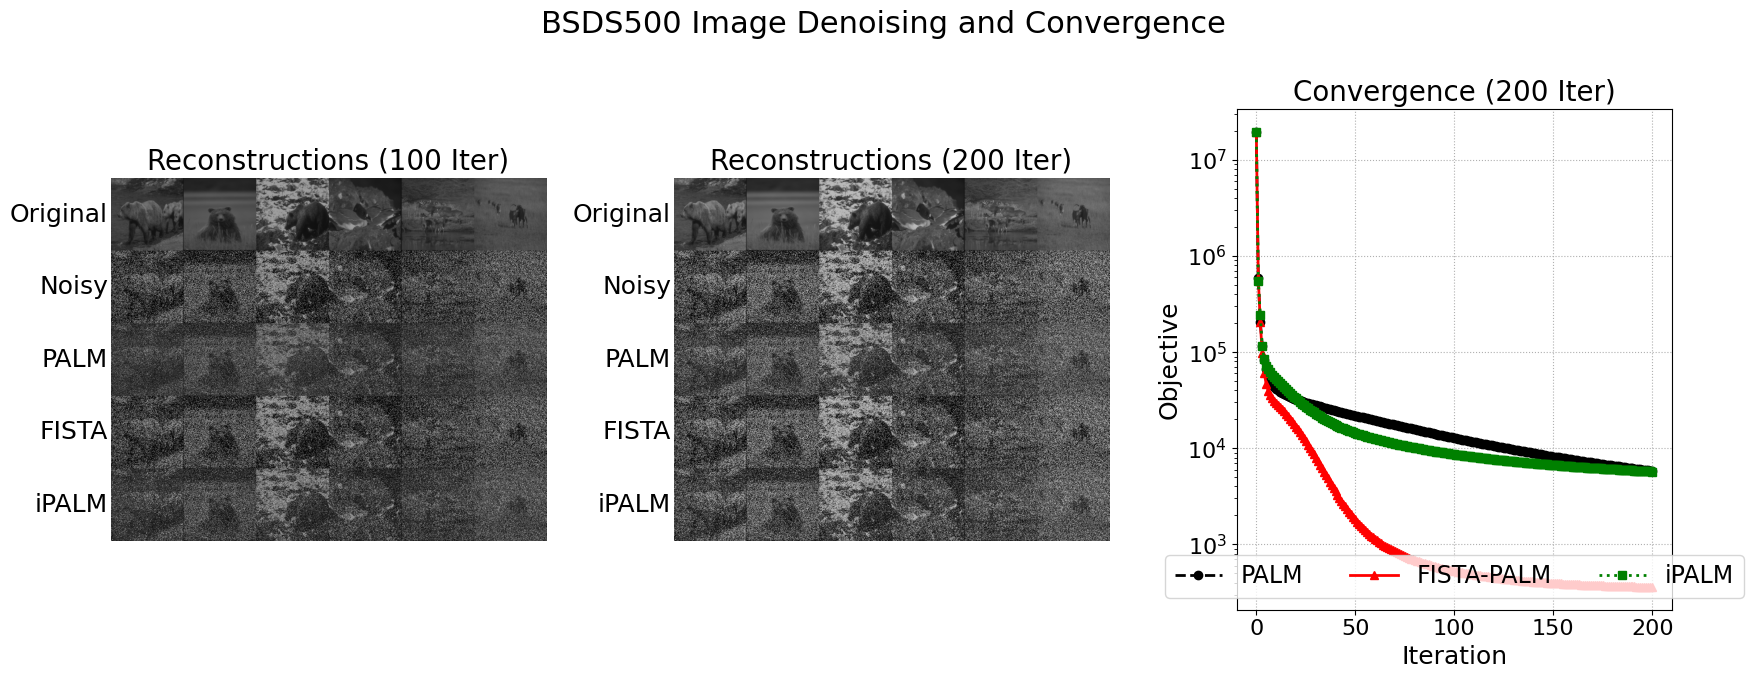

In [6]:
params = {
    "r": r,
    "lam": lam,
    "noise": 0.3,
    "iter": max_iter,
}

plot_berkeley_recon_and_loss(
    img_100,
    img_200,
    histories,
    image_size=image_size,
    row_labels=["Original", "Noisy", "PALM", "FISTA", "iPALM"],
    save_path=make_fig_path(ROOT, "bsds500_denoising", params),
)

In [7]:
df = pd.DataFrame(records)

save_table(
    df,
    ROOT,
    "bsds500_denoising_summary",
    params,
)

df

,Method,Objective @ Iter 100,Objective @ Iter 200,Final Objective,Iterations
0,PALM,12813.596297,5803.315657,5803.315657,200
1,FISTA-PALM,531.345187,360.123435,360.123435,200
2,iPALM,8660.485104,5720.609193,5720.609193,200


## Observations

- **FISTA-PALM clearly outperforms both PALM and iPALM on the BSD500 denoising task**, achieving a substantially lower objective value (≈360 vs ≈5800–8600 at 200 iterations).

- **The convergence gap emerges very early and widens quickly**:
  - FISTA-PALM rapidly reduces the objective within the first ~50 iterations  
  - PALM and iPALM decrease much more slowly and plateau at significantly higher values

- **iPALM provides only a modest improvement over PALM**, with slightly better convergence and reconstruction quality, but remains far behind FISTA-PALM.

- **Reconstruction quality reflects the optimisation results**:
  - FISTA-PALM produces noticeably cleaner images with clearer structures and reduced noise  
  - PALM and iPALM reconstructions remain heavily corrupted even after 200 iterations

- Overall, this experiment shows that **acceleration is crucial for effective denoising**, with FISTA-PALM achieving both faster convergence and substantially better visual recovery on BSD500 images.